In [2]:
import os
import sys
import yaml
import time
import zarr
import argparse
from glob import glob
from datetime import datetime, timedelta

import numpy as np
import xarray as xr

sys.path.insert(0, os.path.realpath('../libs/'))
import solar_utils as su

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
def hourly_range_numpy(year):
    # start at midnight Jan 1 of the year
    start = np.datetime64(f'{year}-01-01T00:00', 'ns')
    # end at midnight Jan 1 of the next year
    end   = np.datetime64(f'{year+1}-01-01T00:00', 'ns')
    # step by one hour
    hours = np.arange(start, end, np.timedelta64(1, 'h'), dtype='datetime64[ns]')
    return hours

In [11]:
year = 2029
dt = hourly_range_numpy(year)

In [6]:
static_name = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/static/C404_GP_static.zarr'
ds_static = xr.open_zarr(static_name)
lon_WRF = ds_static['XLONG'].values
lat_WRF = ds_static['XLAT'].values
elev_WRF = ds_static['HGT_M'].values

In [9]:
#lat_WRF[:, -1]

In [6]:
lon_grid = lon_WRF
lat_grid = lat_WRF

t0 = f"{year}-01-01"
t1 = f"{year}-12-31 23:00"
toa_radiation = su.get_toa_radiation(t0, t1)

TSI = np.zeros((len(dt), 336, 336))

for i in range(336):
    start = time.time()
    print(i)
    
    for j in range(336):
        lon_val = lon_WRF[i, j]
        lat_val = lat_WRF[i, j]
        elev = elev_WRF[i, j]
        out = su.get_solar_radiation_loc(toa_radiation, lon_val, lat_val, elev, t0, t1, step_freq='1h')
        TSI[:, i, j] = out['tsi'].values[:, 0, 0]
        
    end = time.time()
    print(f"Elapsed time: {end - start:.4f} seconds")

/glade/work/ksha/miniconda3/envs/credit/lib/python3.11/site-packages/pvlib/solarposition.py:263: UserWarning: Reloading spa to use numba
  warnings.warn('Reloading spa to use numba')


0
Elapsed time: 28.1545 seconds
1



KeyboardInterrupt



In [12]:
out['tsi'].values.shape

(8760, 1, 1)

In [7]:
south_north = np.arange(336).astype(np.float32)
west_east = np.arange(336).astype(np.float32)

ds = xr.Dataset(
    data_vars={"TSI": (("time", "south_north", "west_east"), TSI)},
    coords={
        "time":        dt,
        "south_north": south_north,
        "west_east":   west_east
    }
)

# zarr encodings
dict_encoding = {}

chunk_size_3d = dict(chunks=(1, 336, 336))
compress = zarr.Blosc(cname='zstd', clevel=1, shuffle=zarr.Blosc.SHUFFLE, blocksize=0)
dict_encoding['TSI'] = {'compressor': compress, **chunk_size_3d}

save_name = f'/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_GP/solar/solar_GP_{year}.zarr'
ds.to_zarr(save_name, mode='w', consolidated=True, compute=True, encoding=dict_encoding)
print(save_name)

/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_GP/solar/solar_GP_2030.zarr


In [11]:
np.sum(np.isnan(TSI))

0

In [12]:
ds_solar = xr.open_zarr(f'/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_GP/solar/solar_GP_{year}.zarr')
ds_solar

<xarray.Dataset>
Dimensions:      (time: 8760, south_north: 336, west_east: 336)
Coordinates:
  * south_north  (south_north) float32 0.0 1.0 2.0 3.0 ... 333.0 334.0 335.0
  * time         (time) datetime64[ns] 2029-01-01 ... 2029-12-31T23:00:00
  * west_east    (west_east) float32 0.0 1.0 2.0 3.0 ... 332.0 333.0 334.0 335.0
Data variables:
    TSI          (time, south_north, west_east) float64 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>

In [15]:
ds_solar.to_array().isnull().any().compute().item()

False

In [29]:
ds_solar['time'][15]

<xarray.DataArray 'time' ()>
array('2029-01-01T15:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2029-01-01T15:00:00

In [16]:
TSI = ds_solar['TSI'].values

/glade/derecho/scratch/ksha/tmp/ipykernel_29328/3410785577.py:1: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(lon_WRF, lat_WRF, TSI[15, ...], cmap=plt.cm.jet)


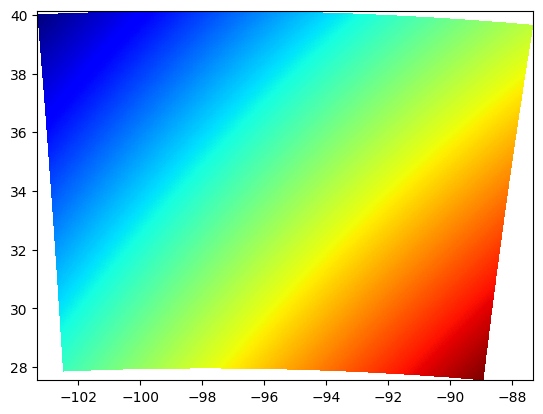

In [27]:
plt.pcolormesh(lon_WRF, lat_WRF, TSI[15, ...], cmap=plt.cm.jet)

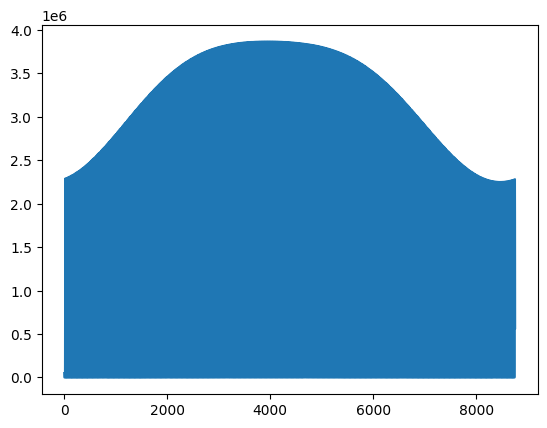

In [22]:
plt.plot(TSI.mean(axis=(1, 2)))

In [10]:
# ds_C404 = xr.open_zarr(f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/all_in_one/C404_GP_{year}.zarr')
# ds_C404 

In [ ]:
# xr.merge([ds_solar, ds_C404])